# Fig SX

## Checking whether low dimensionality is a result of connections being set to zero or whether the pattern of connectivity is similar across voxels

In [1]:
import pickle
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from sklearn.linear_model import LinearRegression
# from sklearn import metrics as skm
import statsmodels.api as sm

import wbplot
import matplotlib.image as img
import matplotlib.colors as clrs
from matplotlib import colorbar

# # import RSMtools
# import plottools

from tqdm import tqdm

import sys
sys.path.append('../src')
import utils
import plot_utils

from brainsmash.mapgen.base import Base
from brainsmash.mapgen.stats import pearsonr, pairwise_r
from brainsmash.mapgen.stats import nonparp

In [2]:
projdir = '/home/ln275/f_mc1689_1/multitask_generalization/'
subProjDir = projdir + 'data/derivatives/RSM_ActFlow/'
helpfiles_dir = projdir + 'docs/experimentfiles/'
figoutdir = projdir + 'docs/figures/working/vertexwiseFC/'
fcdir = projdir + 'data/derivatives/FC_new/'

In [3]:
subIDs=['02','03','06','08','10','12','14','18','20',
        '22','24','25','26','27','28','29','30','31']

onlyRestSubIdx = [ 0, 1, 3, 4, 6, 7, 8,10,11,
                  12,20,13,21,14,22,15,23,16] # Use when dealing with full subjects' data (n=24)

nSub = len(subIDs)
nParcels = 360
nVertices = 59412
nSessions = 2
nTaskCond = 96

glasserfilename = helpfiles_dir + 'Q1-Q6_RelatedParcellation210.LR.CorticalAreas_dil_Colors.32k_fs_RL.dlabel.nii'
glasser = np.squeeze(nib.load(glasserfilename).get_fdata())

networkdef = np.loadtxt(helpfiles_dir + 'cortex_parcel_network_assignments.txt')
networkNames = ['VIS1','VIS2','SMN','CON','DAN','LAN','FPN','AUD','DMN','PMULTI','VMM','ORA']

In [4]:
allsub_conn_dim = utils.get_FC_dimensionality()
meansub_conn_dim = np.mean(allsub_conn_dim, axis=0)

In [5]:
# Sparsity at three thresholds (0.0001, 0.00005, 0.00001)

with open(fcdir + 'allsub_sparsity_count.pkl', 'rb') as f:
    allsub_sparsity_count = pickle.load(f)

In [6]:
allsub_sparsity_count.shape

(18, 360, 3)

In [7]:
meansub_sparsity_count = np.mean(allsub_sparsity_count, axis=0)

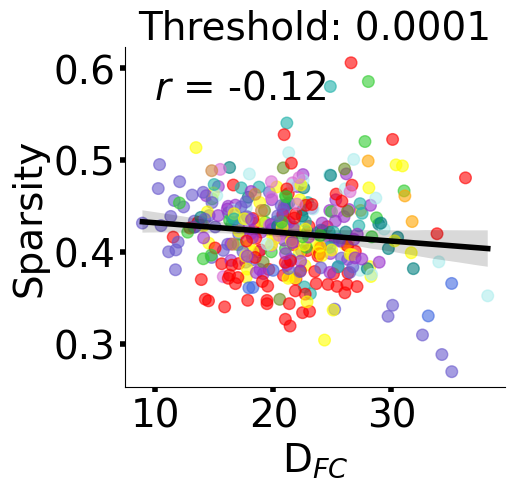

In [18]:
X = meansub_conn_dim
Y = meansub_sparsity_count[:,0]

RAaxis = 'full'
xlabel = r'D$_{FC}$'
ylabel = 'Sparsity'
outname = figoutdir + 'meansub_ConnDim_vs_Sparsity_0.0001thr.pdf'

fig = plot_utils.customScatterPlot(X,Y,RAaxis,xlabel,ylabel,outname,legLoc='TL',ymin=None,ymax=None,xmin=None,xmax=None,
                            invert_xaxis=False,deg=1,xtickbins=3,ytickbins=4,
                            plotwidth=5.25,showstat=True)
plt.title('Threshold: 0.0001', fontsize=28)
plt.tight_layout()
plt.savefig(outname,transparent=True)

plt.show()

In [9]:
stats.pearsonr(X,Y)

PearsonRResult(statistic=-0.11556933926309133, pvalue=0.028343467399583402)

In [21]:
x = meansub_conn_dim
y = meansub_sparsity_count[:,0]

obs_r, pval = utils.get_brainsmash_correlation(x,y,n_perm=1000)
print('obs_r = ',obs_r, ', pval = ',pval)

obs_r =  -0.11556933926309133 , pval =  0.1


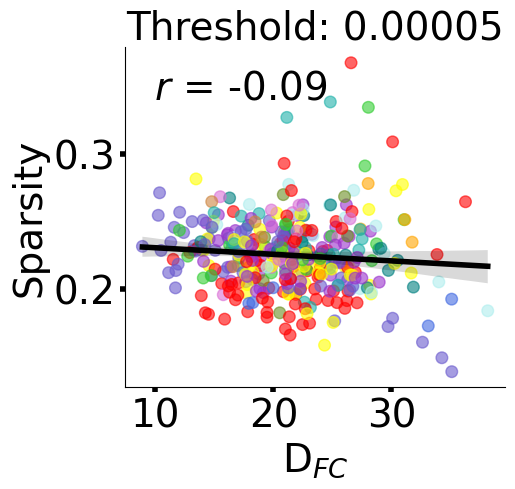

In [19]:
X = meansub_conn_dim
Y = meansub_sparsity_count[:,1]

RAaxis = 'full'
xlabel = r'D$_{FC}$'
ylabel = 'Sparsity'
outname = figoutdir + 'meansub_ConnDim_vs_Sparsity_0.00005thr.pdf'

plot_utils.customScatterPlot(X,Y,RAaxis,xlabel,ylabel,outname,legLoc='TL',ymin=None,ymax=None,xmin=None,xmax=None,
                            invert_xaxis=False,deg=1,xtickbins=3,ytickbins=4,
                            plotwidth=5.25,showstat=True)
plt.title('Threshold: 0.00005', fontsize=28)
plt.tight_layout()
plt.savefig(outname,transparent=True)

plt.show()

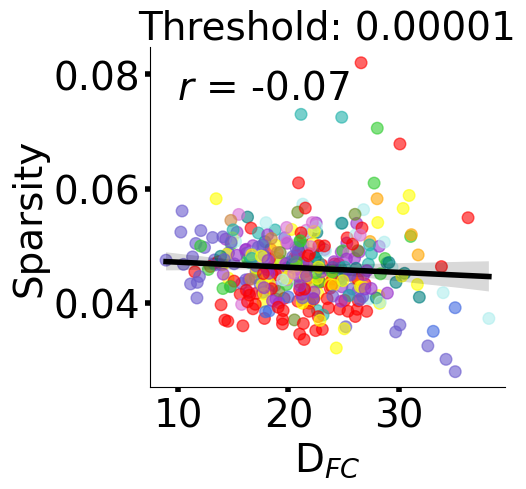

In [20]:
X = meansub_conn_dim
Y = meansub_sparsity_count[:,2]

RAaxis = 'full'
xlabel = r'D$_{FC}$'
ylabel = 'Sparsity'
outname = figoutdir + 'meansub_ConnDim_vs_Sparsity_0.00001thr.pdf'


plot_utils.customScatterPlot(X,Y,RAaxis,xlabel,ylabel,outname,legLoc='TL',ymin=None,ymax=None,xmin=None,xmax=None,
                            invert_xaxis=False,deg=1,xtickbins=3,ytickbins=4,
                            plotwidth=5.25,showstat=True)

plt.title('Threshold: 0.00001', fontsize=28)
plt.tight_layout()
plt.savefig(outname,transparent=True)


plt.show()